# Detector Noise Visualization from hThetaMulti

This notebook visualizes the detector noise generated by the `detector_noise()` method from the `hThetaMulti` dataset class. We'll analyze the time-domain and frequency-domain characteristics of noise for H1, L1, and V1 detectors.

## 1. Import Required Libraries

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
import os

# Add source directory to path
sys.path.insert(0, '/Users/tarineccleston/Desktop/starccato/starccato-flow/src')

from starccato_flow.data.h_theta_multi import hThetaMulti
from starccato_flow.utils.defaults import Y_LENGTH, SAMPLING_RATE

# Set matplotlib parameters for better plots
plt.style.use('seaborn-v0_8-darkgrid')
print(f"Y_LENGTH: {Y_LENGTH}")
print(f"SAMPLING_RATE: {SAMPLING_RATE}")
print("Libraries imported successfully!")

MPS device found
Y_LENGTH: 256
SAMPLING_RATE: 0.000244140625
Libraries imported successfully!


## 2. Load Dataset and Initialize Detector

In [2]:
# Create synthetic sample data for demonstration
n_samples = 5
n_params = 4

# Generate synthetic signals
s = np.random.randn(Y_LENGTH, n_samples).astype(np.float32)

# Generate synthetic parameters (intrinsic)
theta = np.random.randn(n_samples, n_params).astype(np.float32)

# Generate sky parameters
ra = np.random.uniform(-np.pi, np.pi, n_samples).astype(np.float32)
dec = np.random.uniform(-np.pi/2, np.pi/2, n_samples).astype(np.float32)
d = np.random.uniform(1, 20, n_samples).astype(np.float32)

# Initialize dataset with multi-detector configuration
dataset = hThetaMulti(
    detectors=['H1', 'L1', 'V1'],
    batch_size=1,
    detector_noise_on=True,
    s=s,
    theta=theta,
    ra=ra,
    dec=dec,
    d=d,
    shared_max_strain=1e-20,
    random_polarization=True,
    seed=42
)

print(f"Dataset initialized with {len(dataset)} samples")
print(f"Detectors: {dataset.detectors}")


hThetaMulti Dataset - Parameter Bounds (8 parameters)
INTRINSIC PARAMETERS:
  beta1_IC_b          : [   -1.426418,     1.592164]
  omega_0(rad|s)      : [   -1.565398,     1.676619]
  A(km)               : [   -0.392662,     1.948662]
  Ye_c_b              : [   -1.163326,     1.131046]

EXTRINSIC (SKY) PARAMETERS:
  ra                  : [   -3.141593,     3.141593]
  dec                 : [   -1.570796,     1.570796]
  d                   : [    0.000000,    20.000000]
  psi                 : [    0.000000,     3.141593]


=== Multi-Channel Dataset Info ===
Detectors: H1, L1, V1 (3 channels)
Signals per channel: 5
Multi-channel shape: (5, 3, 256)
Parameter dimension: 8
Parameters include theta + sky: [ra, dec, d, polar_angle]
Dataset initialized with 5 samples
Detectors: ['H1', 'L1', 'V1']


/Users/tarineccleston/Desktop/starccato/starccato-flow/src/starccato_flow/data/h_theta_multi.py:241: RuntimeWarning: divide by zero encountered in power
  psd = 1e-49 * (pow(x, - 4.14) - 5 / x2 + 111 * (1 - x2 + 0.5 * x2 * x2) / (1 + 0.5 * x2))
/Users/tarineccleston/Desktop/starccato/starccato-flow/src/starccato_flow/data/h_theta_multi.py:241: RuntimeWarning: divide by zero encountered in divide
  psd = 1e-49 * (pow(x, - 4.14) - 5 / x2 + 111 * (1 - x2 + 0.5 * x2 * x2) / (1 + 0.5 * x2))
/Users/tarineccleston/Desktop/starccato/starccato-flow/src/starccato_flow/data/h_theta_multi.py:241: RuntimeWarning: invalid value encountered in subtract
  psd = 1e-49 * (pow(x, - 4.14) - 5 / x2 + 111 * (1 - x2 + 0.5 * x2 * x2) / (1 + 0.5 * x2))


## 3. Generate Noise Samples

In [3]:
# Generate noise samples for each detector using different seed offsets
noise_samples_h1 = []
noise_samples_l1 = []
noise_samples_v1 = []
n_noise_realizations = 10

print("Generating noise samples...")
for i in range(n_noise_realizations):
    # Generate noise for each detector with different seeds
    noise_h1 = dataset.detector_noise(seed_offset=i*1000, detector='H1').flatten()
    noise_l1 = dataset.detector_noise(seed_offset=i*1000+100, detector='L1').flatten()
    noise_v1 = dataset.detector_noise(seed_offset=i*1000+200, detector='V1').flatten()
    
    noise_samples_h1.append(noise_h1)
    noise_samples_l1.append(noise_l1)
    noise_samples_v1.append(noise_v1)

# Convert to arrays for easier manipulation
noise_h1_array = np.array(noise_samples_h1)
noise_l1_array = np.array(noise_samples_l1)
noise_v1_array = np.array(noise_samples_v1)

# Average noise across realizations
noise_h1_mean = noise_h1_array.mean(axis=0)
noise_l1_mean = noise_l1_array.mean(axis=0)
noise_v1_mean = noise_v1_array.mean(axis=0)

print(f"Generated {n_noise_realizations} noise realizations for each detector")
print(f"Noise shape: {noise_h1_mean.shape}")
print(f"H1 noise stats - mean: {noise_h1_mean.mean():.2e}, std: {noise_h1_mean.std():.2e}")
print(f"L1 noise stats - mean: {noise_l1_mean.mean():.2e}, std: {noise_l1_mean.std():.2e}")
print(f"V1 noise stats - mean: {noise_v1_mean.mean():.2e}, std: {noise_v1_mean.std():.2e}")

Generating noise samples...
Generated 10 noise realizations for each detector
Noise shape: (256,)
H1 noise stats - mean: -3.76e-38, std: 1.03e-24
L1 noise stats - mean: -1.48e-37, std: 9.12e-25
V1 noise stats - mean: -3.61e-36, std: 6.19e-24


## 4. Plot Time-Domain Noise

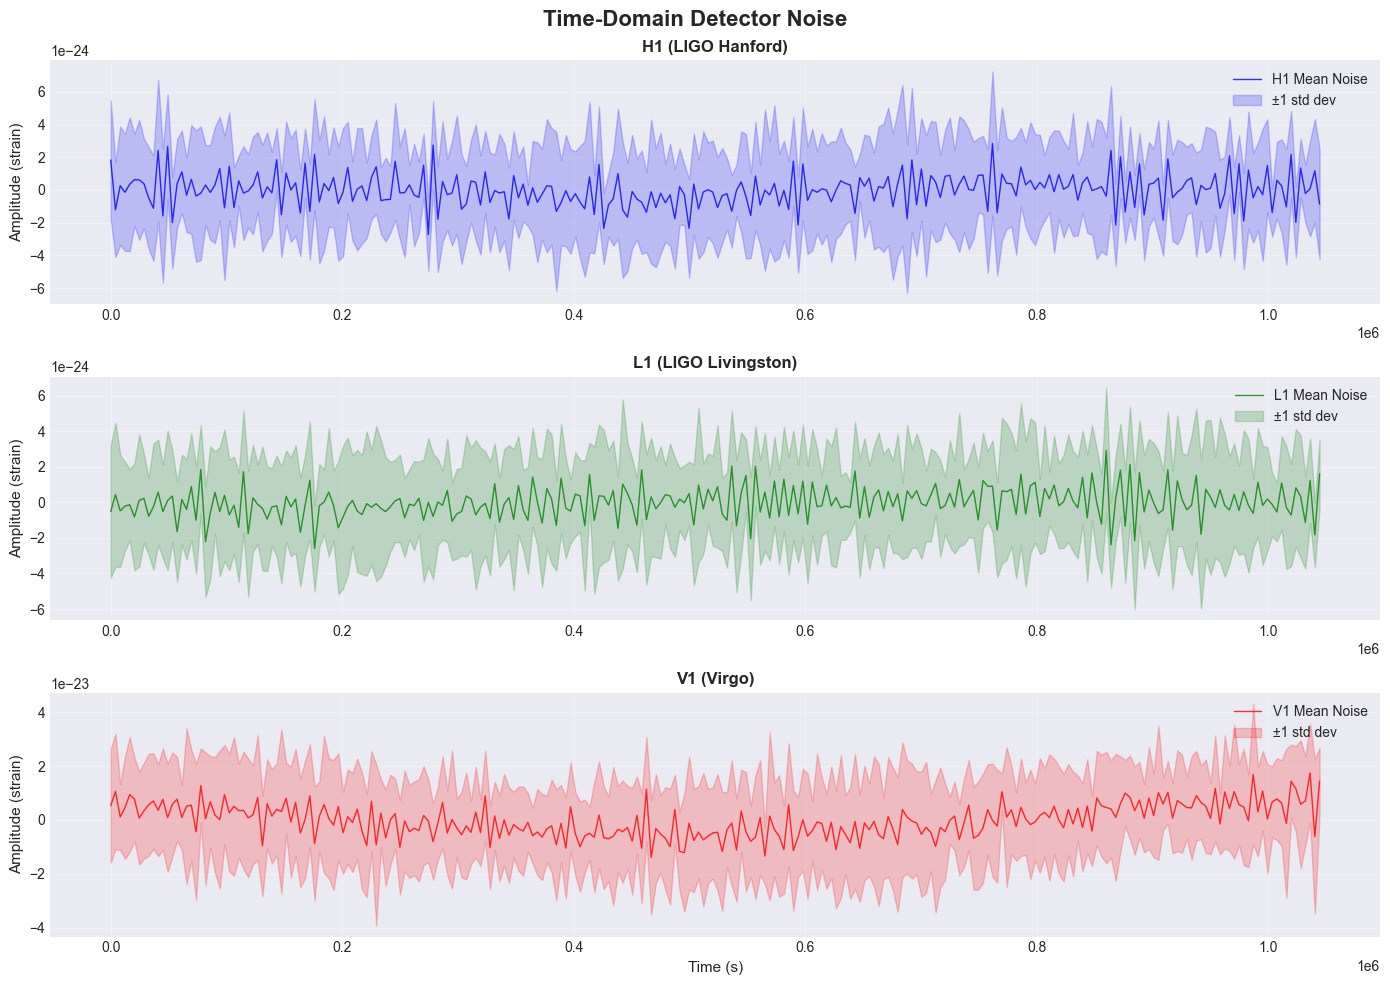

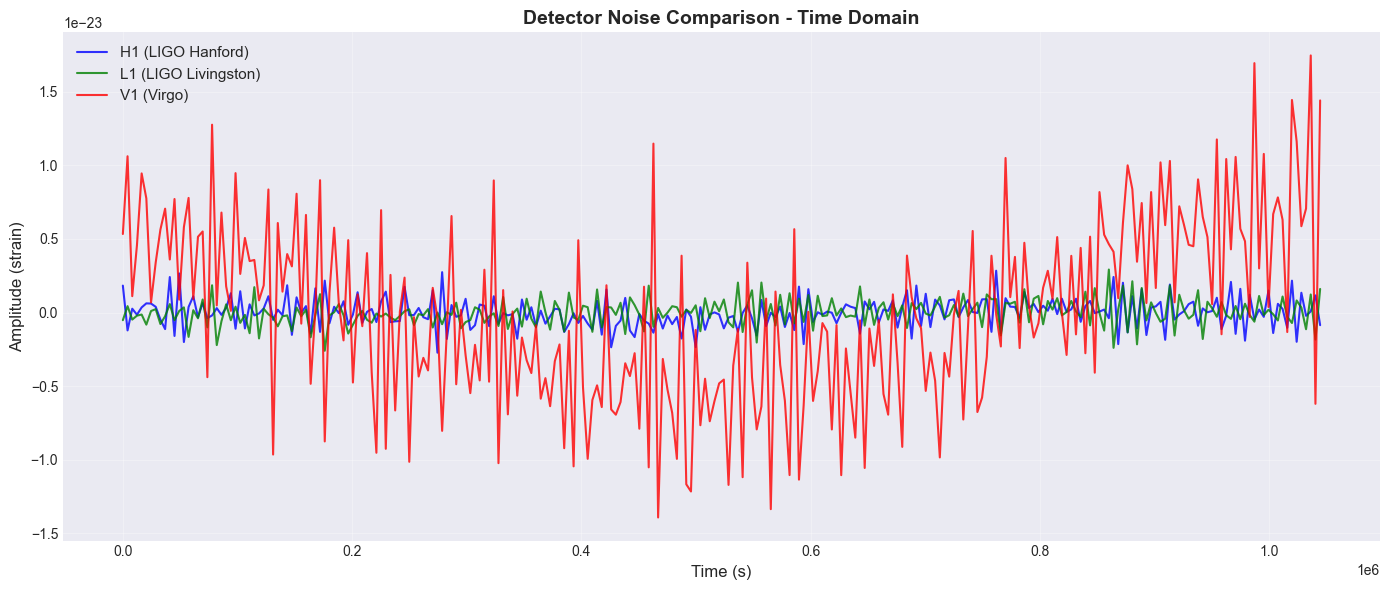

In [4]:
# Create time-domain noise plots
time = np.arange(Y_LENGTH) / SAMPLING_RATE  # time in seconds

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle('Time-Domain Detector Noise', fontsize=16, fontweight='bold')

# Plot H1 noise
axes[0].plot(time, noise_h1_mean, 'b-', linewidth=1, alpha=0.8, label='H1 Mean Noise')
axes[0].fill_between(time, 
                      noise_h1_mean - noise_h1_array.std(axis=0),
                      noise_h1_mean + noise_h1_array.std(axis=0),
                      alpha=0.2, color='blue', label='±1 std dev')
axes[0].set_ylabel('Amplitude (strain)', fontsize=11)
axes[0].set_title('H1 (LIGO Hanford)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper right')

# Plot L1 noise
axes[1].plot(time, noise_l1_mean, 'g-', linewidth=1, alpha=0.8, label='L1 Mean Noise')
axes[1].fill_between(time,
                      noise_l1_mean - noise_l1_array.std(axis=0),
                      noise_l1_mean + noise_l1_array.std(axis=0),
                      alpha=0.2, color='green', label='±1 std dev')
axes[1].set_ylabel('Amplitude (strain)', fontsize=11)
axes[1].set_title('L1 (LIGO Livingston)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper right')

# Plot V1 noise
axes[2].plot(time, noise_v1_mean, 'r-', linewidth=1, alpha=0.8, label='V1 Mean Noise')
axes[2].fill_between(time,
                      noise_v1_mean - noise_v1_array.std(axis=0),
                      noise_v1_mean + noise_v1_array.std(axis=0),
                      alpha=0.2, color='red', label='±1 std dev')
axes[2].set_xlabel('Time (s)', fontsize=11)
axes[2].set_ylabel('Amplitude (strain)', fontsize=11)
axes[2].set_title('V1 (Virgo)', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

# Plot all detectors together for comparison
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(time, noise_h1_mean, 'b-', linewidth=1.5, alpha=0.8, label='H1 (LIGO Hanford)')
ax.plot(time, noise_l1_mean, 'g-', linewidth=1.5, alpha=0.8, label='L1 (LIGO Livingston)')
ax.plot(time, noise_v1_mean, 'r-', linewidth=1.5, alpha=0.8, label='V1 (Virgo)')
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Amplitude (strain)', fontsize=12)
ax.set_title('Detector Noise Comparison - Time Domain', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 5. Plot Frequency-Domain Noise (PSD)

In [5]:
# Compute Power Spectral Density using FFT
def compute_psd(signal, sampling_rate):
    """Compute PSD from time-domain signal using FFT."""
    N = len(signal)
    fft_vals = fft(signal)
    psd = (2.0 / (sampling_rate * N)) * np.abs(fft_vals[:N//2])**2
    freqs = fftfreq(N, 1/sampling_rate)[:N//2]
    return freqs, psd

# Compute PSD for each detector (using mean noise)
freqs_h1, psd_h1 = compute_psd(noise_h1_mean, SAMPLING_RATE)
freqs_l1, psd_l1 = compute_psd(noise_l1_mean, SAMPLING_RATE)
freqs_v1, psd_v1 = compute_psd(noise_v1_mean, SAMPLING_RATE)

# Also compute average PSD from all realizations
psd_h1_all = np.array([compute_psd(noise_h1_array[i], SAMPLING_RATE)[1] for i in range(n_noise_realizations)])
psd_l1_all = np.array([compute_psd(noise_l1_array[i], SAMPLING_RATE)[1] for i in range(n_noise_realizations)])
psd_v1_all = np.array([compute_psd(noise_v1_array[i], SAMPLING_RATE)[1] for i in range(n_noise_realizations)])

psd_h1_mean_all = psd_h1_all.mean(axis=0)
psd_l1_mean_all = psd_l1_all.mean(axis=0)
psd_v1_mean_all = psd_v1_all.mean(axis=0)

print(f"Frequency resolution: {freqs_h1[1] - freqs_h1[0]:.4f} Hz")
print(f"Frequency range: {freqs_h1[1]:.2f} Hz to {freqs_h1[-1]:.2f} Hz")

Frequency resolution: 0.0000 Hz
Frequency range: 0.00 Hz to 0.00 Hz


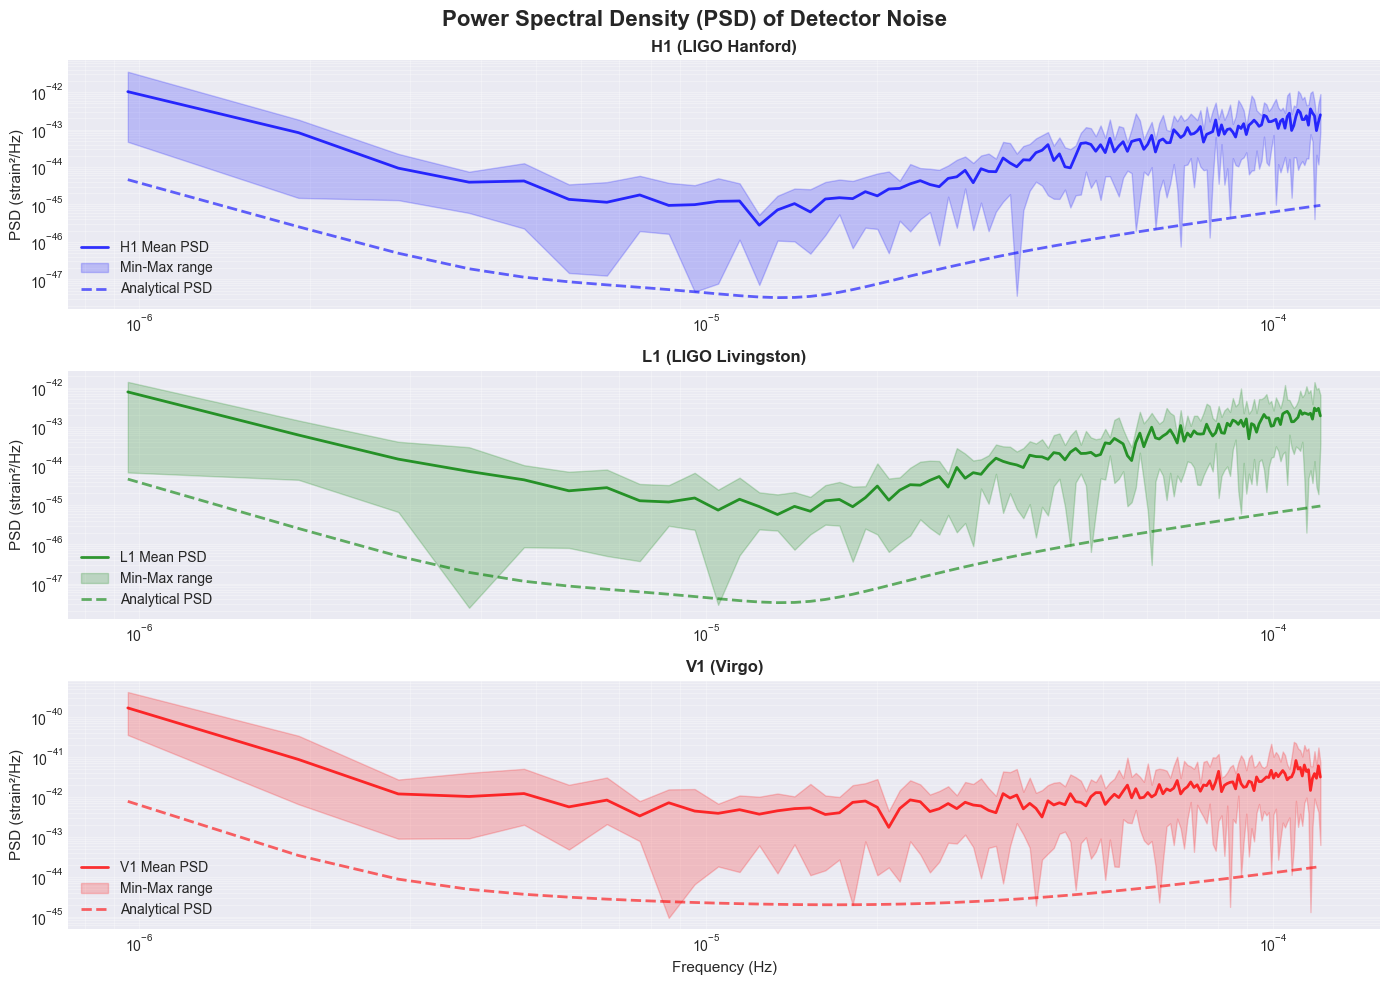

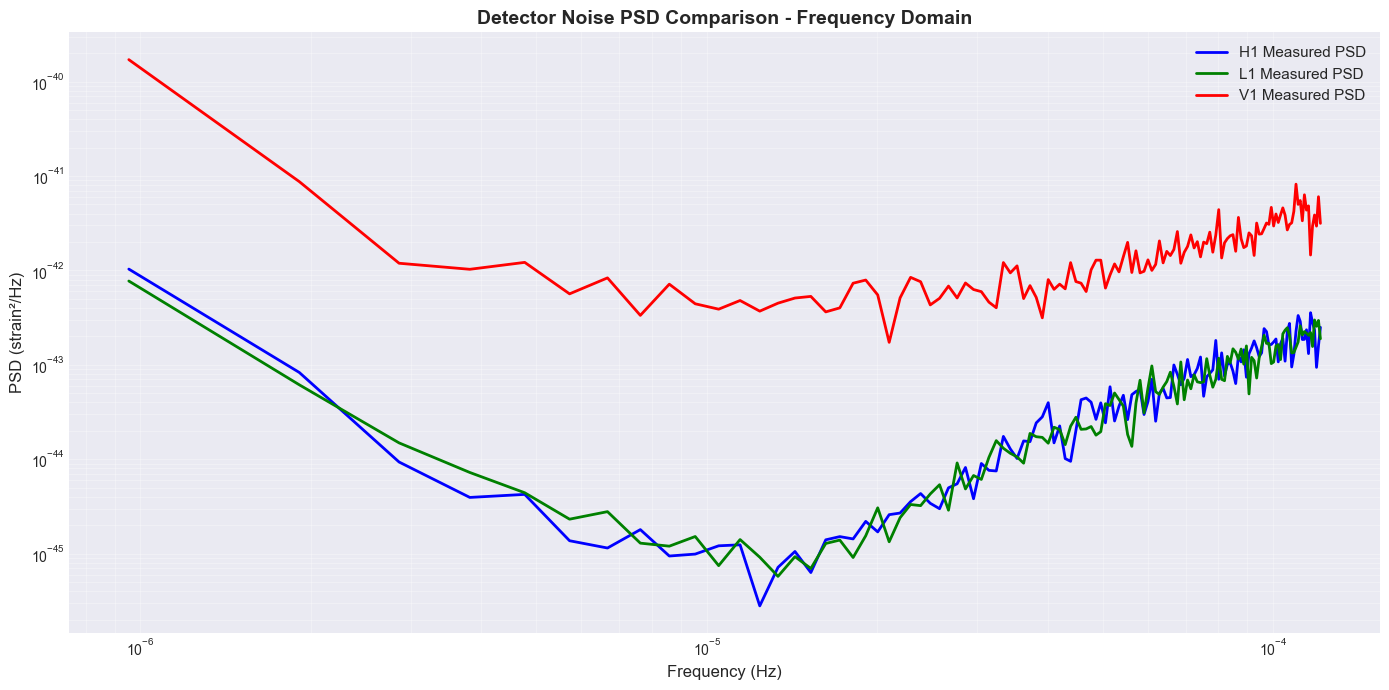

In [6]:
# Plot PSD for each detector
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle('Power Spectral Density (PSD) of Detector Noise', fontsize=16, fontweight='bold')

# Filter out zero frequencies for log-log plot
min_freq_idx = 1  # Skip DC component

# Plot H1 PSD
axes[0].loglog(freqs_h1[min_freq_idx:], psd_h1_mean_all[min_freq_idx:], 'b-', linewidth=2, alpha=0.8, label='H1 Mean PSD')
axes[0].fill_between(freqs_h1[min_freq_idx:],
                      psd_h1_all.min(axis=0)[min_freq_idx:],
                      psd_h1_all.max(axis=0)[min_freq_idx:],
                      alpha=0.2, color='blue', label='Min-Max range')
# Plot analytical PSD
freqs_for_psd = freqs_h1[min_freq_idx:]
analytical_psd_h1 = dataset.AdvLIGOPSD
axes[0].loglog(freqs_for_psd, analytical_psd_h1[min_freq_idx:len(freqs_for_psd)+min_freq_idx],
               'b--', linewidth=2, alpha=0.6, label='Analytical PSD')
axes[0].set_ylabel('PSD (strain²/Hz)', fontsize=11)
axes[0].set_title('H1 (LIGO Hanford)', fontsize=12, fontweight='bold')
axes[0].grid(True, which='both', alpha=0.3)
axes[0].legend(loc='lower left')

# Plot L1 PSD
axes[1].loglog(freqs_l1[min_freq_idx:], psd_l1_mean_all[min_freq_idx:], 'g-', linewidth=2, alpha=0.8, label='L1 Mean PSD')
axes[1].fill_between(freqs_l1[min_freq_idx:],
                      psd_l1_all.min(axis=0)[min_freq_idx:],
                      psd_l1_all.max(axis=0)[min_freq_idx:],
                      alpha=0.2, color='green', label='Min-Max range')
# Plot analytical PSD
axes[1].loglog(freqs_for_psd, analytical_psd_h1[min_freq_idx:len(freqs_for_psd)+min_freq_idx],
               'g--', linewidth=2, alpha=0.6, label='Analytical PSD')
axes[1].set_ylabel('PSD (strain²/Hz)', fontsize=11)
axes[1].set_title('L1 (LIGO Livingston)', fontsize=12, fontweight='bold')
axes[1].grid(True, which='both', alpha=0.3)
axes[1].legend(loc='lower left')

# Plot V1 PSD
axes[2].loglog(freqs_v1[min_freq_idx:], psd_v1_mean_all[min_freq_idx:], 'r-', linewidth=2, alpha=0.8, label='V1 Mean PSD')
axes[2].fill_between(freqs_v1[min_freq_idx:],
                      psd_v1_all.min(axis=0)[min_freq_idx:],
                      psd_v1_all.max(axis=0)[min_freq_idx:],
                      alpha=0.2, color='red', label='Min-Max range')
# Plot analytical PSD
analytical_psd_v1 = dataset.VirgoPSD
axes[2].loglog(freqs_for_psd, analytical_psd_v1[min_freq_idx:len(freqs_for_psd)+min_freq_idx],
               'r--', linewidth=2, alpha=0.6, label='Analytical PSD')
axes[2].set_xlabel('Frequency (Hz)', fontsize=11)
axes[2].set_ylabel('PSD (strain²/Hz)', fontsize=11)
axes[2].set_title('V1 (Virgo)', fontsize=12, fontweight='bold')
axes[2].grid(True, which='both', alpha=0.3)
axes[2].legend(loc='lower left')

plt.tight_layout()
plt.show()

# Combined PSD plot
fig, ax = plt.subplots(figsize=(14, 7))
ax.loglog(freqs_h1[min_freq_idx:], psd_h1_mean_all[min_freq_idx:], 'b-', linewidth=2, label='H1 Measured PSD')
ax.loglog(freqs_l1[min_freq_idx:], psd_l1_mean_all[min_freq_idx:], 'g-', linewidth=2, label='L1 Measured PSD')
ax.loglog(freqs_v1[min_freq_idx:], psd_v1_mean_all[min_freq_idx:], 'r-', linewidth=2, label='V1 Measured PSD')
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('PSD (strain²/Hz)', fontsize=12)
ax.set_title('Detector Noise PSD Comparison - Frequency Domain', fontsize=14, fontweight='bold')
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 6. Compare Noise Across Detectors


Noise Statistics Comparison Across Detectors
              H1 (LIGO Hanford)  L1 (LIGO Livingston)    V1 (Virgo)
mean              -3.761582e-38         -1.481123e-37 -3.611119e-36
std                3.269061e-24          3.139418e-24  1.961030e-23
min               -1.181775e-23         -1.008840e-23 -6.521867e-23
max                1.210839e-23          1.068737e-23  7.814307e-23
rms                3.276521e-24          3.145244e-24  1.982850e-23
peak_to_peak       2.392613e-23          2.077577e-23  1.433617e-22



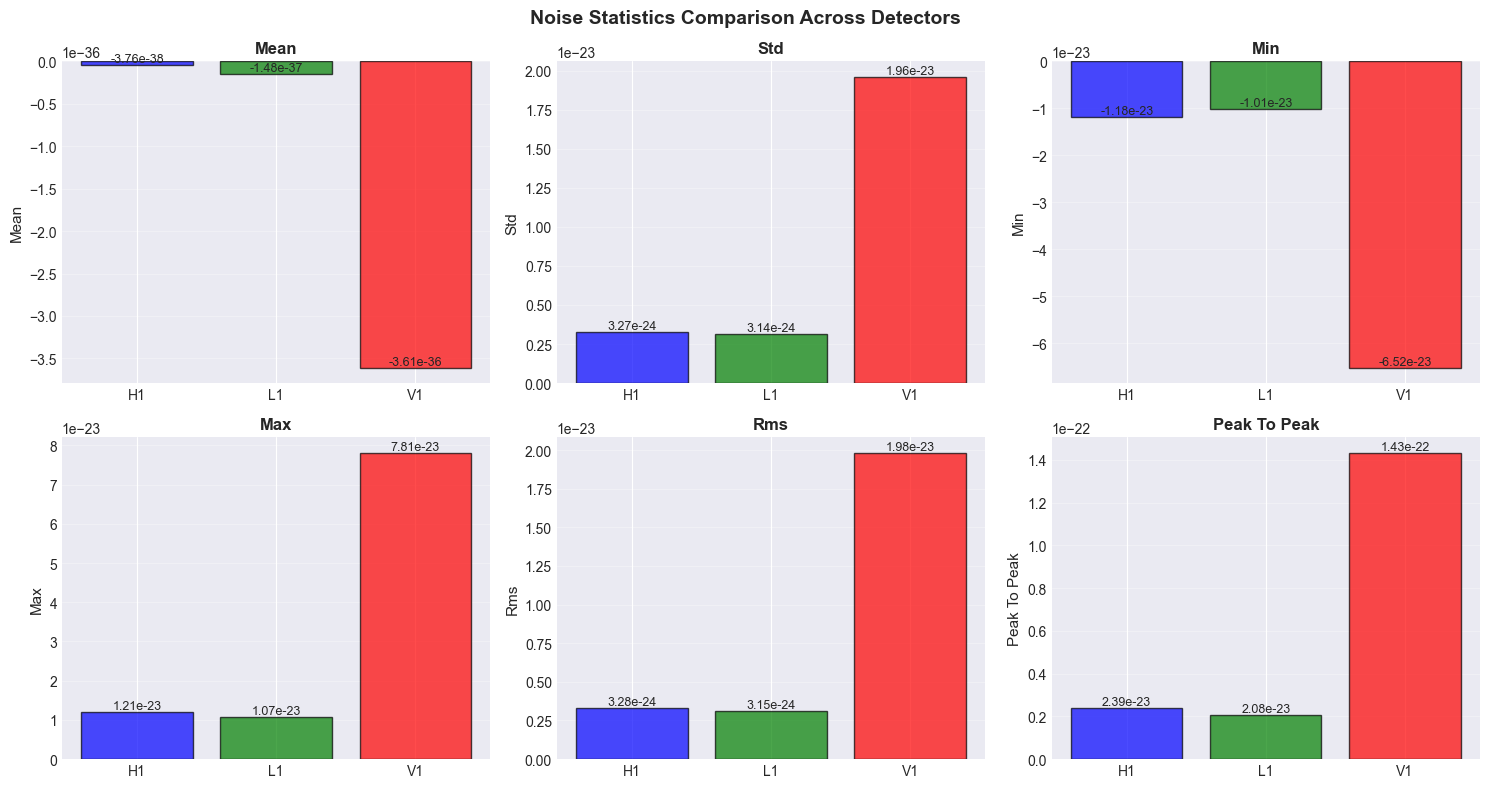

In [7]:
# Calculate noise statistics for each detector
def calculate_statistics(noise_array):
    """Calculate various statistics from noise array (n_realizations, samples)."""
    stats = {
        'mean': noise_array.mean(axis=1).mean(),
        'std': noise_array.std(axis=1).mean(),
        'min': noise_array.min(),
        'max': noise_array.max(),
        'rms': np.sqrt((noise_array**2).mean()),
        'peak_to_peak': noise_array.max() - noise_array.min()
    }
    return stats

stats_h1 = calculate_statistics(noise_h1_array)
stats_l1 = calculate_statistics(noise_l1_array)
stats_v1 = calculate_statistics(noise_v1_array)

# Create comparison table
import pandas as pd

stats_df = pd.DataFrame({
    'H1 (LIGO Hanford)': stats_h1,
    'L1 (LIGO Livingston)': stats_l1,
    'V1 (Virgo)': stats_v1
})

print("\n" + "="*70)
print("Noise Statistics Comparison Across Detectors")
print("="*70)
print(stats_df.to_string())
print("="*70 + "\n")

# Create bar plots for noise statistics comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Noise Statistics Comparison Across Detectors', fontsize=14, fontweight='bold')

detectors = ['H1', 'L1', 'V1']
stats_keys = ['mean', 'std', 'min', 'max', 'rms', 'peak_to_peak']
stats_dict = {'H1': stats_h1, 'L1': stats_l1, 'V1': stats_v1}

for idx, key in enumerate(stats_keys):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    values = [stats_dict[det][key] for det in detectors]
    colors = ['blue', 'green', 'red']
    bars = ax.bar(detectors, values, color=colors, alpha=0.7, edgecolor='black')
    
    ax.set_ylabel(key.replace('_', ' ').title(), fontsize=11)
    ax.set_title(key.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2e}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Analyze Noise Statistics

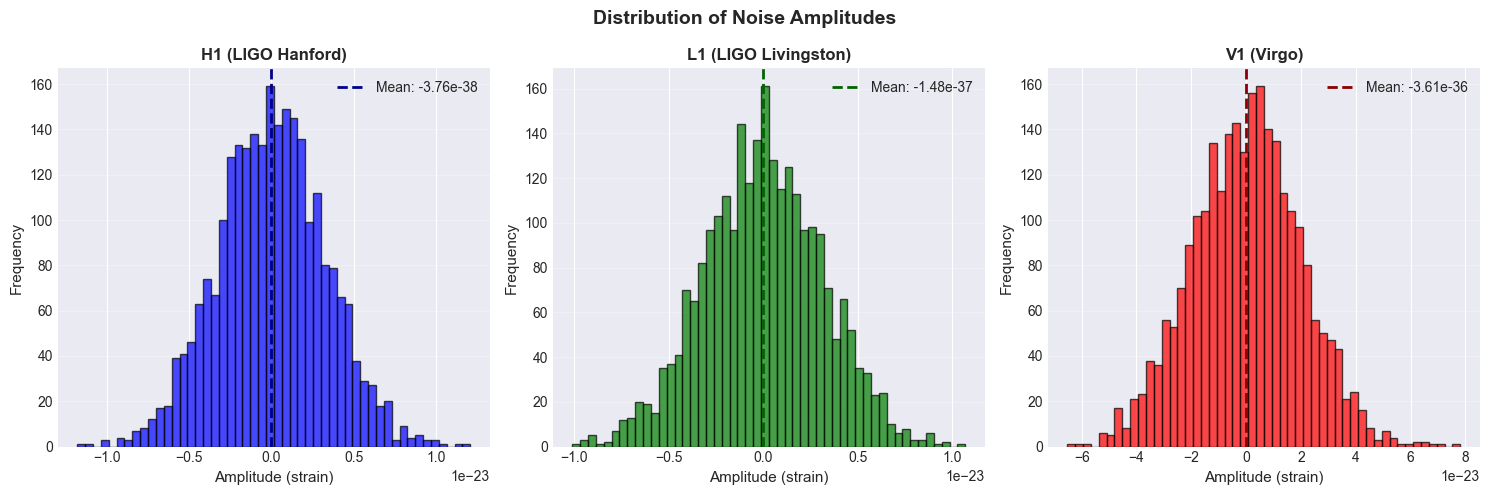


Noise Correlation Analysis
Correlation H1-L1: 0.017483
Correlation H1-V1: 0.071121
Correlation L1-V1: 0.057903



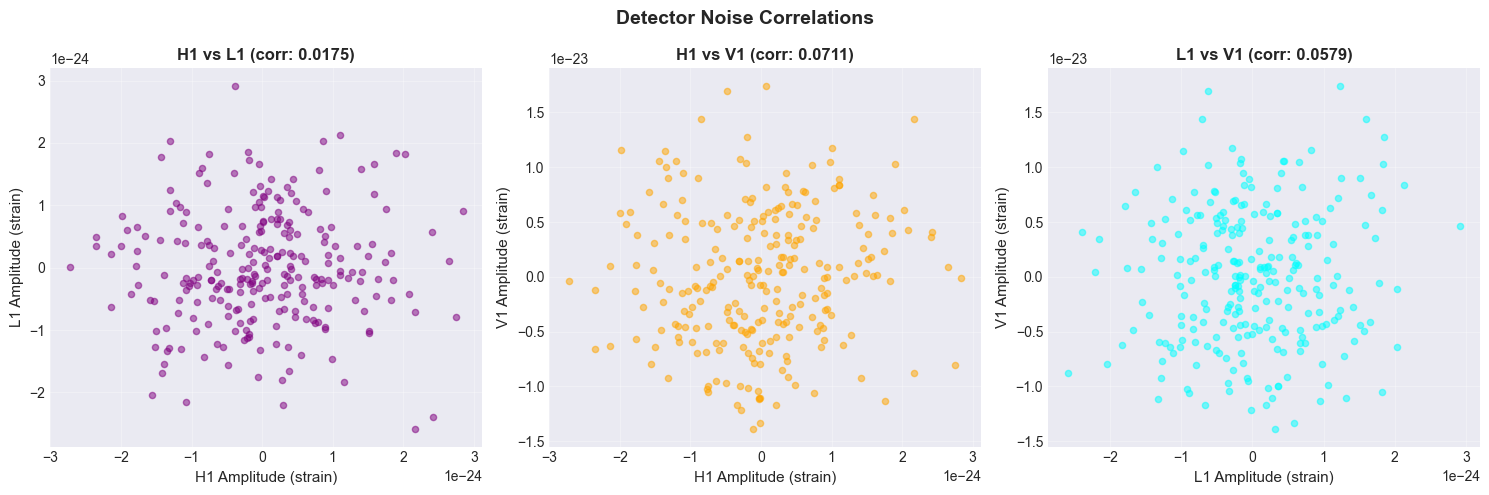


Detailed Noise Analysis Summary

H1 (LIGO Hanford):
  RMS Amplitude: 1.03e-24 strain
  Peak-to-Peak: 5.56e-24 strain
  Amplitude Range: [-2.72e-24, 2.84e-24] strain

L1 (LIGO Livingston):
  RMS Amplitude: 9.12e-25 strain
  Peak-to-Peak: 5.51e-24 strain
  Amplitude Range: [-2.59e-24, 2.92e-24] strain

V1 (Virgo):
  RMS Amplitude: 6.19e-24 strain
  Peak-to-Peak: 3.14e-23 strain
  Amplitude Range: [-1.39e-23, 1.75e-23] strain

Noise Characteristics:
  Number of realizations analyzed: 10
  Samples per realization: 256
  Duration per sample: 1048576.0000 seconds
  Sampling rate: 0.000244140625 Hz



In [8]:
# Create histograms of noise amplitudes
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribution of Noise Amplitudes', fontsize=14, fontweight='bold')

# Flatten the 2D arrays for histogram
h1_flat = noise_h1_array.flatten()
l1_flat = noise_l1_array.flatten()
v1_flat = noise_v1_array.flatten()

axes[0].hist(h1_flat, bins=50, color='blue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Amplitude (strain)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('H1 (LIGO Hanford)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axvline(h1_flat.mean(), color='darkblue', linestyle='--', linewidth=2, label=f'Mean: {h1_flat.mean():.2e}')
axes[0].legend()

axes[1].hist(l1_flat, bins=50, color='green', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Amplitude (strain)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('L1 (LIGO Livingston)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].axvline(l1_flat.mean(), color='darkgreen', linestyle='--', linewidth=2, label=f'Mean: {l1_flat.mean():.2e}')
axes[1].legend()

axes[2].hist(v1_flat, bins=50, color='red', alpha=0.7, edgecolor='black')
axes[2].set_xlabel('Amplitude (strain)', fontsize=11)
axes[2].set_ylabel('Frequency', fontsize=11)
axes[2].set_title('V1 (Virgo)', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')
axes[2].axvline(v1_flat.mean(), color='darkred', linestyle='--', linewidth=2, label=f'Mean: {v1_flat.mean():.2e}')
axes[2].legend()

plt.tight_layout()
plt.show()

# Correlation analysis between detectors
correlation_h1_l1 = np.corrcoef(noise_h1_mean, noise_l1_mean)[0, 1]
correlation_h1_v1 = np.corrcoef(noise_h1_mean, noise_v1_mean)[0, 1]
correlation_l1_v1 = np.corrcoef(noise_l1_mean, noise_v1_mean)[0, 1]

print("\n" + "="*70)
print("Noise Correlation Analysis")
print("="*70)
print(f"Correlation H1-L1: {correlation_h1_l1:.6f}")
print(f"Correlation H1-V1: {correlation_h1_v1:.6f}")
print(f"Correlation L1-V1: {correlation_l1_v1:.6f}")
print("="*70 + "\n")

# Create scatter plots for correlation
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Detector Noise Correlations', fontsize=14, fontweight='bold')

# H1 vs L1
axes[0].scatter(noise_h1_mean, noise_l1_mean, alpha=0.5, s=20, color='purple')
axes[0].set_xlabel('H1 Amplitude (strain)', fontsize=11)
axes[0].set_ylabel('L1 Amplitude (strain)', fontsize=11)
axes[0].set_title(f'H1 vs L1 (corr: {correlation_h1_l1:.4f})', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# H1 vs V1
axes[1].scatter(noise_h1_mean, noise_v1_mean, alpha=0.5, s=20, color='orange')
axes[1].set_xlabel('H1 Amplitude (strain)', fontsize=11)
axes[1].set_ylabel('V1 Amplitude (strain)', fontsize=11)
axes[1].set_title(f'H1 vs V1 (corr: {correlation_h1_v1:.4f})', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# L1 vs V1
axes[2].scatter(noise_l1_mean, noise_v1_mean, alpha=0.5, s=20, color='cyan')
axes[2].set_xlabel('L1 Amplitude (strain)', fontsize=11)
axes[2].set_ylabel('V1 Amplitude (strain)', fontsize=11)
axes[2].set_title(f'L1 vs V1 (corr: {correlation_l1_v1:.4f})', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*70)
print("Detailed Noise Analysis Summary")
print("="*70)
print("\nH1 (LIGO Hanford):")
print(f"  RMS Amplitude: {np.sqrt((noise_h1_mean**2).mean()):.2e} strain")
print(f"  Peak-to-Peak: {noise_h1_mean.max() - noise_h1_mean.min():.2e} strain")
print(f"  Amplitude Range: [{noise_h1_mean.min():.2e}, {noise_h1_mean.max():.2e}] strain")

print("\nL1 (LIGO Livingston):")
print(f"  RMS Amplitude: {np.sqrt((noise_l1_mean**2).mean()):.2e} strain")
print(f"  Peak-to-Peak: {noise_l1_mean.max() - noise_l1_mean.min():.2e} strain")
print(f"  Amplitude Range: [{noise_l1_mean.min():.2e}, {noise_l1_mean.max():.2e}] strain")

print("\nV1 (Virgo):")
print(f"  RMS Amplitude: {np.sqrt((noise_v1_mean**2).mean()):.2e} strain")
print(f"  Peak-to-Peak: {noise_v1_mean.max() - noise_v1_mean.min():.2e} strain")
print(f"  Amplitude Range: [{noise_v1_mean.min():.2e}, {noise_v1_mean.max():.2e}] strain")

print("\nNoise Characteristics:")
print(f"  Number of realizations analyzed: {n_noise_realizations}")
print(f"  Samples per realization: {Y_LENGTH}")
print(f"  Duration per sample: {Y_LENGTH / SAMPLING_RATE:.4f} seconds")
print(f"  Sampling rate: {SAMPLING_RATE} Hz")
print("="*70 + "\n")